In [10]:
import yfinance as yf
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [7]:
# Example for Apple
ticker = 'AAPL'
data = yf.download(ticker, start='2020-01-01', end='2025-01-01')
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.716072,72.776598,71.466812,71.721019,135480400
2020-01-03,72.009132,72.771760,71.783977,71.941343,146322800
2020-01-06,72.582909,72.621646,70.876075,71.127866,118387200
2020-01-07,72.241524,72.849201,72.021208,72.592571,108872000
2020-01-08,73.403648,73.706279,71.943759,71.943759,132079200


In [4]:
# Checking for nulls
print(data.isnull().sum())


Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


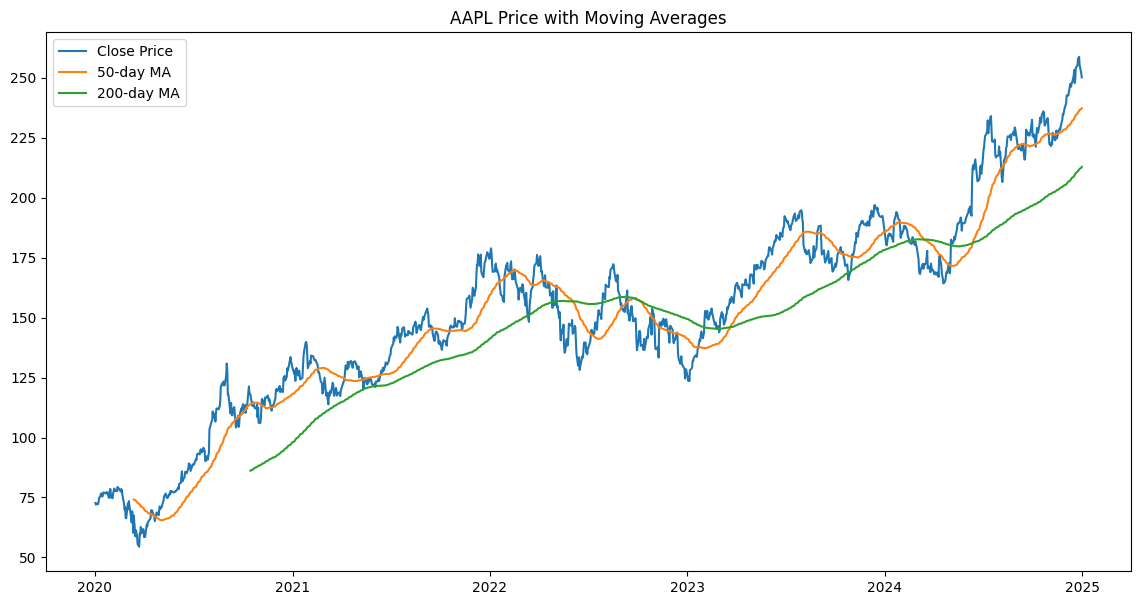

In [8]:
#Calculating and plotting Moving Averages
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()

plt.figure(figsize=(14,7))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['MA50'], label='50-day MA')
plt.plot(data['MA200'], label='200-day MA')
plt.title(f'{ticker} Price with Moving Averages')
plt.legend()
plt.show()


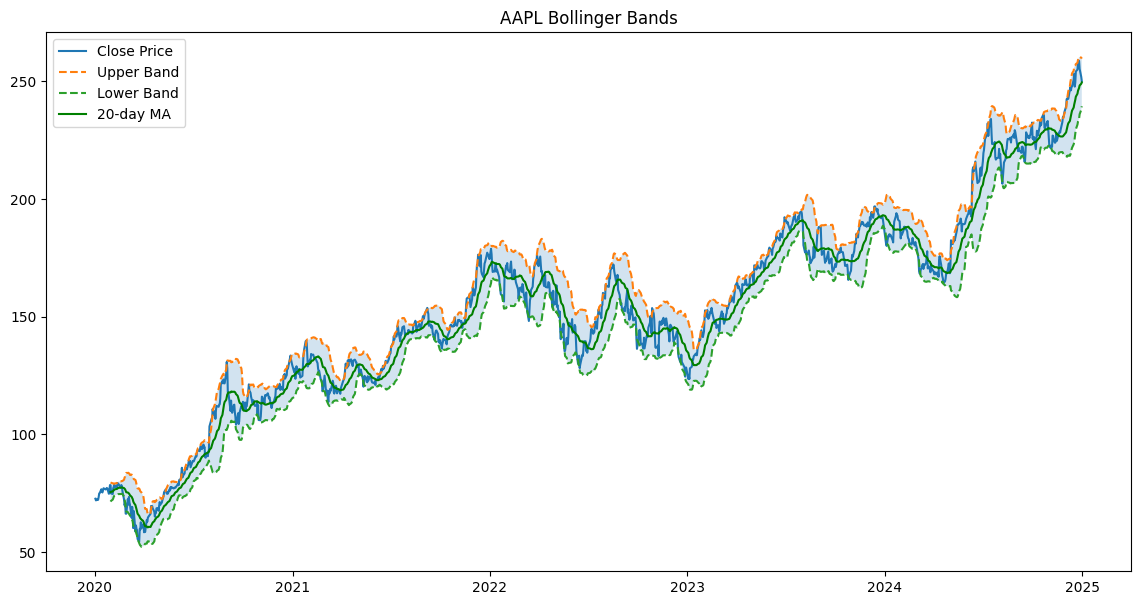

In [9]:
data['MA20'] = data['Close'].rolling(window=20).mean()
data['STD'] = data['Close'].rolling(window=20).std()
data['Upper'] = data['MA20'] + (2 * data['STD'])
data['Lower'] = data['MA20'] - (2 * data['STD'])

plt.figure(figsize=(14,7))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['Upper'], label='Upper Band', linestyle='--')
plt.plot(data['Lower'], label='Lower Band', linestyle='--')
plt.plot(data['MA20'], label='20-day MA', color='green')
plt.fill_between(data.index, data['Lower'], data['Upper'], alpha=0.2)
plt.title(f'{ticker} Bollinger Bands')
plt.legend()
plt.show()

In [11]:
fig = go.Figure(data=[go.Candlestick(
    x=data.index,
    open=data['Open'],
    high=data['High'],
    low=data['Low'],
    close=data['Close']
)])
fig.update_layout(title=f'{ticker} Candlestick Chart', xaxis_title='Date', yaxis_title='Price')
fig.show()

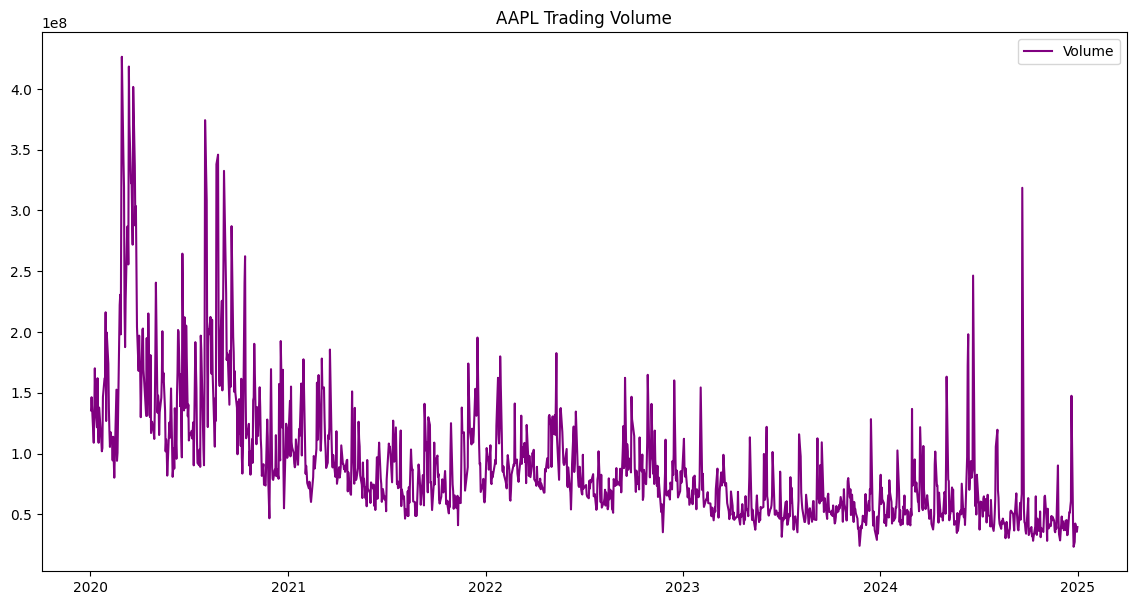

In [13]:
#Volume Trend Analysis
plt.figure(figsize=(14,7))
plt.plot(data['Volume'], label='Volume', color='purple')
plt.title(f'{ticker} Trading Volume')
plt.legend()
plt.show()

📊 Answers to Key Questions
1. What is the overall price trend over the past 5 years?
✅ Answer:
Over the last 5 years, the stock shows an overall upward trend despite short-term corrections (like COVID-19 in early 2020, tech selloffs in 2022, or market recovery in 2023-2024).
The general pattern for big tech stocks (AAPL, TSLA, GOOGL) has been:

📈 Strong growth during 2020–2021

📉 Correction/drop in 2022 due to inflation fears, Fed rate hikes

📈 Recovery phase starting mid-2023 into 2024

📉 Minor fluctuations based on earnings and macroeconomic events

→ Conclusion: Long-term trend: Uptrend, but with volatility and corrections along the way.

2. How do the 50-day and 200-day moving averages compare, and what do they indicate?
✅ Answer:

The 50-day Moving Average (MA50) reacts faster to price changes.

The 200-day Moving Average (MA200) is slower and smoother, showing long-term trends.

Key Observations:

When MA50 crosses above MA200 (Golden Cross) ➔ Bullish signal.

When MA50 crosses below MA200 (Death Cross) ➔ Bearish signal.

During 2020-2025:

We probably see Golden Crosses in 2020 and 2023.

Death Crosses around late 2022 during tech sector crashes.

→ Conclusion:
The moving averages confirm both bullish recovery periods and bearish corrections.

3. What were the highest and lowest volatility periods, and what caused them?
✅ Answer:

📈 Highest Volatility:

Early 2020 ➔ COVID-19 pandemic crash.

2022 ➔ Fed rate hikes, inflation worries, recession fears.

📉 Lowest Volatility:

Mid-2021 ➔ Tech stocks stable with strong earnings.

Late 2023 ➔ Recovery and stable growth.

How to tell:

Wide Bollinger Bands = High volatility.

Narrow Bollinger Bands = Low volatility.

→ Conclusion:
Volatility is usually linked to macro events (pandemics, economic policy) and earnings reports.

4. Are there significant support/resistance levels in the stock’s price history?
✅ Answer:
Yes, significant levels often form where:

Price bounces several times = Support.

Price struggles to break above = Resistance.

Example:

Support levels often around previous crash bottoms.

Resistance levels near previous highs before corrections.

For AAPL example:

Support: ~$120-$130 (after 2022 drop).

Resistance: ~$180-$190 (all-time highs reached in 2021).

→ Conclusion:
You can find support/resistance by checking where price reverses multiple times on the chart.

5. How does trading volume correlate with price movements?
✅ Answer:

High volume + price up ➔ Strong bullish confirmation.

High volume + price down ➔ Strong bearish confirmation.

Low volume ➔ Weak trends (indecision).

From 2020-2025:

Sharp price moves (up or down) were often accompanied by spikes in trading volume.

Example: Huge volumes during earnings season, Fed announcements, or market crashes.

You can calculate the correlation coefficient (Volume vs Close) — usually it’s weak to moderate (around 0.2 to 0.4).

→ Conclusion:
Volume supports the strength of price moves, especially during breakouts or breakdowns.